## MA3700 V-n Diagram Sea Level

This is a notebook for the use of sketching the V-n diagram.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
sns.set()

### `pyplot` Parameters

We set the parameters for `pyplot` here.

In [2]:
plt.rcParams["figure.figsize"] = (20,20)
plt.rcParams["axes.labelsize"] = 20
plt.rcParams["axes.titlesize"] = 20
plt.rcParams['lines.linewidth'] = 3
plt.rcParams['lines.markersize'] = 20
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20

### Density Input

For this notebook to work we will have to input the density.

In [3]:
density = 1.225

### Constants

We define the following constants as follows:

In [4]:
mass = 8300
weight = 8300 * 9.81 
V_C = 537 / 3.6
V_D = 667 / 3.6
area = 30.91
span = 17.0
mean_chord = 1.997
max_lift_coeff = 1.53
min_lift_coeff = -1.12
lift_slope = 4.33
print("Force of weight (N): ", weight)
print("Cruise speed (m/s): ", V_C)
print("Dive speed (m/s): ", V_D)

Force of weight (N):  81423.0
Cruise speed (m/s):  149.16666666666666
Dive speed (m/s):  185.27777777777777


We find the lift stall curve coefficients:

In [5]:
pstallcoeff = (density * area * max_lift_coeff)/(2 * weight)
print("Positive lift stall curve coefficient: ", pstallcoeff)

Positive lift stall curve coefficient:  0.0003557537028849342


In [6]:
nstallcoeff = (density * area * min_lift_coeff)/(2 * weight)
print("Negative lift stall curve coefficient: ", nstallcoeff)

Negative lift stall curve coefficient:  -0.0002604210112621741


We proceed to find the BCAR load factors:

In [7]:
n_1 = 2.1 + 24000/(2.20462 * mass + 10000) # Changed in Version 3
n_2 = 0.75 * n_1
n_3 = 1

if n_2 < 2:
    n_2 = 2

print("n_1: ", n_1)
print("n_2: ", n_2)
print("n_3: ", n_3)

n_1:  2.948106104858567
n_2:  2.211079578643925
n_3:  1


We proceed to find the positive and negative design manoeuvering speeds.

In [8]:
V_A = ((2 * n_1 * weight)/(density * area * max_lift_coeff))**(0.5)
V_F = ((-2 * n_3 * weight)/(density * area * min_lift_coeff))**(0.5)
print("V_A: ", V_A)
print("V_F: ", V_F)

V_A:  91.03257769531757
V_F:  61.96721663429186


We set up the diagram and figure for `pyplot` here.

In [9]:
%%capture
fig = plt.figure()
ax = fig.gca()
ax.set_xticks(np.arange(0, 200, 10))
ax.set_yticks(np.arange(-5, 5, 0.2))
print("Diagram set up.")

We try to draw the positive stall curve with the following code here:

In [10]:
domain_posstall = np.arange(0.0, V_A, 0.1)
def positivestall(t):
    return (pstallcoeff) * (t ** 2)
# plt.plot(domain_posstall, positivestall(domain_posstall), color='b')

We try to draw the negative stall curve with the following code here:

In [11]:
domain_negstall = np.arange(0.0, V_F, 0.1)
def negativestall(t):
    return (nstallcoeff) * (t ** 2)
# plt.plot(domain_negstall, negativestall(domain_negstall), color='b')

We try to draw the positive limit load factor curve with the following code here:

In [12]:
domain_poslimit = np.arange(V_A, V_C, 0.1)
def poslimit(t):
    return (n_1 + t - t)
# plt.plot(domain_poslimit, poslimit(domain_poslimit), color='b')

We try to draw the negative limit load factor curve with the following code here:

In [13]:
domain_neglimit = np.arange(V_F, V_C, 0.1)
def neglimit(t):
    return (-n_3 + t - t)
# plt.plot(domain_neglimit, neglimit(domain_neglimit), color='b')

We try to draw the high speed limit vertical line with the following code here:

In [14]:
# plt.vlines(x=V_D, ymin=-n_3, ymax=n_1, colors='b')

The algorithm for the beta lines is as follows.
Firstly, we find the gradient of the top line by taking `(n_2 - n_1)/(V_C - V_A)`
We assign it to a `pos_beta_grad` variable. This will inherently be negative.

We will find the y-intercept by taking `n_1 - pos_beta_grad * V_C`.
We then assign this y-intercept to `pos_beta_intercept`.

We assign it to a (-`pos_beta_grad`) variable to `neg_beta_grad`. This will inherently be
positive. 

We will find the y-intercept by taking `n_3 - neg_beta_grad * V_C`.
We then assign this y-intercept to `neg_beta_intercept`.

We will have to find the limits of the vertical line:
This will be:
`pos_dive_ylimit = pos_beta_grad * V_D + pos_beta_intercept`
and
`neg_dive_ylimit = neg_beta_grad * V_D + neg_beta_intercept`.
We will assign it to the limits of the vertical line.
`plt.vlines(x=V_D, ymin=neg_dive_ylimit, ymax=pos_dive_ylimit, colors='b')`

Lastly, we will have to figure out the appropriate domains:
`domain_betaline = np.arange(V_C, V_D, 0.1)`

And then draw the beta lines accordingly.
```
def betalimit(m,c,t):
    return (m*t + c)
plt.plot(domain_betaline, betalimit(pos_beta_grad, pos_beta_intercept, domain_betaline), color='k')
plt.plot(domain_betaline, betalimit(neg_beta_grad, neg_beta_intercept, domain_betaline), color='k')
```

In [15]:
pos_beta_grad = (n_2 - n_1)/(V_D - V_C)
pos_beta_intercept = n_1 - (pos_beta_grad * V_C)
neg_beta_grad = 0 - pos_beta_grad
neg_beta_intercept = -n_3 - (neg_beta_grad * V_C)
pos_dive_ylimit = (pos_beta_grad * V_D) + pos_beta_intercept
print("Positive dive limit: ", pos_dive_ylimit)
neg_dive_ylimit = (neg_beta_grad * V_D) + neg_beta_intercept
print("Negative dive limit: ", neg_dive_ylimit)
domain_betaline = np.arange(V_C, V_D, 0.1)
def betalimit(m,c,t):
    return (m*t + c)

Positive dive limit:  2.211079578643925
Negative dive limit:  -0.2629734737853586


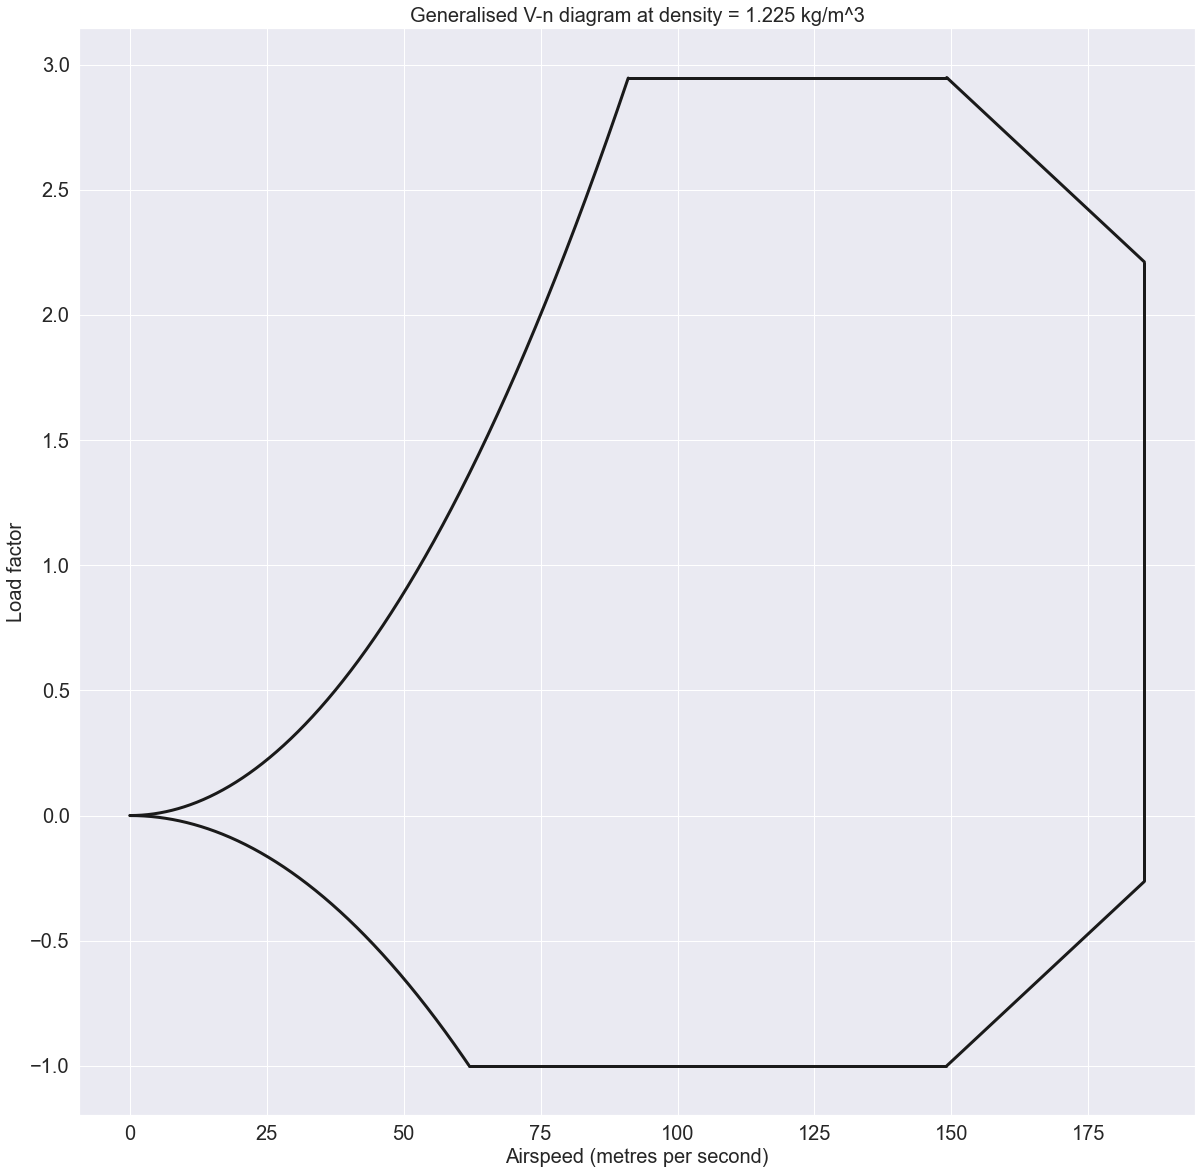

In [16]:
plt.plot(domain_posstall, positivestall(domain_posstall), color='k')
plt.plot(domain_negstall, negativestall(domain_negstall), color='k')
plt.plot(domain_poslimit, poslimit(domain_poslimit), color='k')
plt.plot(domain_neglimit, neglimit(domain_neglimit), color='k')
plt.vlines(x=V_D, ymin=neg_dive_ylimit, ymax=pos_dive_ylimit, colors='k')
plt.plot(domain_betaline, betalimit(pos_beta_grad, pos_beta_intercept, domain_betaline), color='k')
plt.plot(domain_betaline, betalimit(neg_beta_grad, neg_beta_intercept, domain_betaline), color='k')

# Append the plots above.

plt.ylabel('Load factor')
plt.xlabel('Airspeed (metres per second)')
title_str = str("Generalised V-n diagram at density = " + str(density) + " kg/m^3")
plt.title(title_str)
plt.grid(True)
plt.show()

## Gust V-n Diagram

Here is the algorithm used to plot the gust V-n diagram:

The first part requires the solution of the intersection between the gust stall curve and the
gust line u = 20. Iteration is required:

0. Pick epsilon between 1e-5 where difference between n_AG - nAG < 1e-5
1. Guess n_AG = n_1
2. Substitute n_1 to find the gust speed V_AG using the positive lift stall curve `(n_stall = pstallcoeff * (V_stall ** 2)`.
3. Substiute V_AG to find n_AG2
4. Iterate WHILE n_AG2 - n_AG > 1e-5. If it does, stop the algorithm. Assign n_AG2 = n_AG, print the value.

In [17]:
u_stall = 20
eps = 1e-5
n_AG = n_1
n_AG2 = 0
while True:
    # V_AG = ((2*n_AG*weight)/(density*area*max_lift_coeff))**(0.5)
    V_AG = ((n_AG)/(pstallcoeff))**(0.5)
    # print(V_AG)
    n_AG2 = 1 + (density * V_AG * area * lift_slope * u_stall)/(2 * weight)
    # print(n_AG)
    # print(n_AG2)
    if abs(n_AG - n_AG2) < eps:
        break
    else:
        n_AG = n_AG2
    # print(n_AG)
    # print(n_AG2)
print("V_AG: ", V_AG)
print("n_AG: ", n_AG)

V_AG:  88.39950212292699
n_AG:  2.7800273414036205


In [18]:
u_cruise = 15.25
V_CG = V_C
n_CG = 1 + (density * V_CG * area * lift_slope * u_cruise)/(2 * weight)
print("V_CG: ", V_CG)
print("n_CG: ", n_CG)

V_CG:  149.16666666666666
n_CG:  3.290274424318707


In [19]:
u_dive = 7.5
V_DG = V_D
n_DG = 1 + (density * V_DG * area * lift_slope * u_dive)/(2 * weight)
print("V_DG: ", V_DG)
print("n_DG: ", n_DG)

V_DG:  185.27777777777777
n_DG:  2.399041158549847


In [20]:
def gust_line(V_1, V_2, n_1, n_2):
    """Procedure. Plots the y-value associated with the gust line. V_2 > V_1"""
    gradient = (n_2 - n_1)/(V_2 - V_1)
    intercept = n_2 - gradient * V_2
    domain = np.arange(V_1, V_2, 0.1)
    plt.plot(domain, ((gradient * domain) + intercept), color='b')

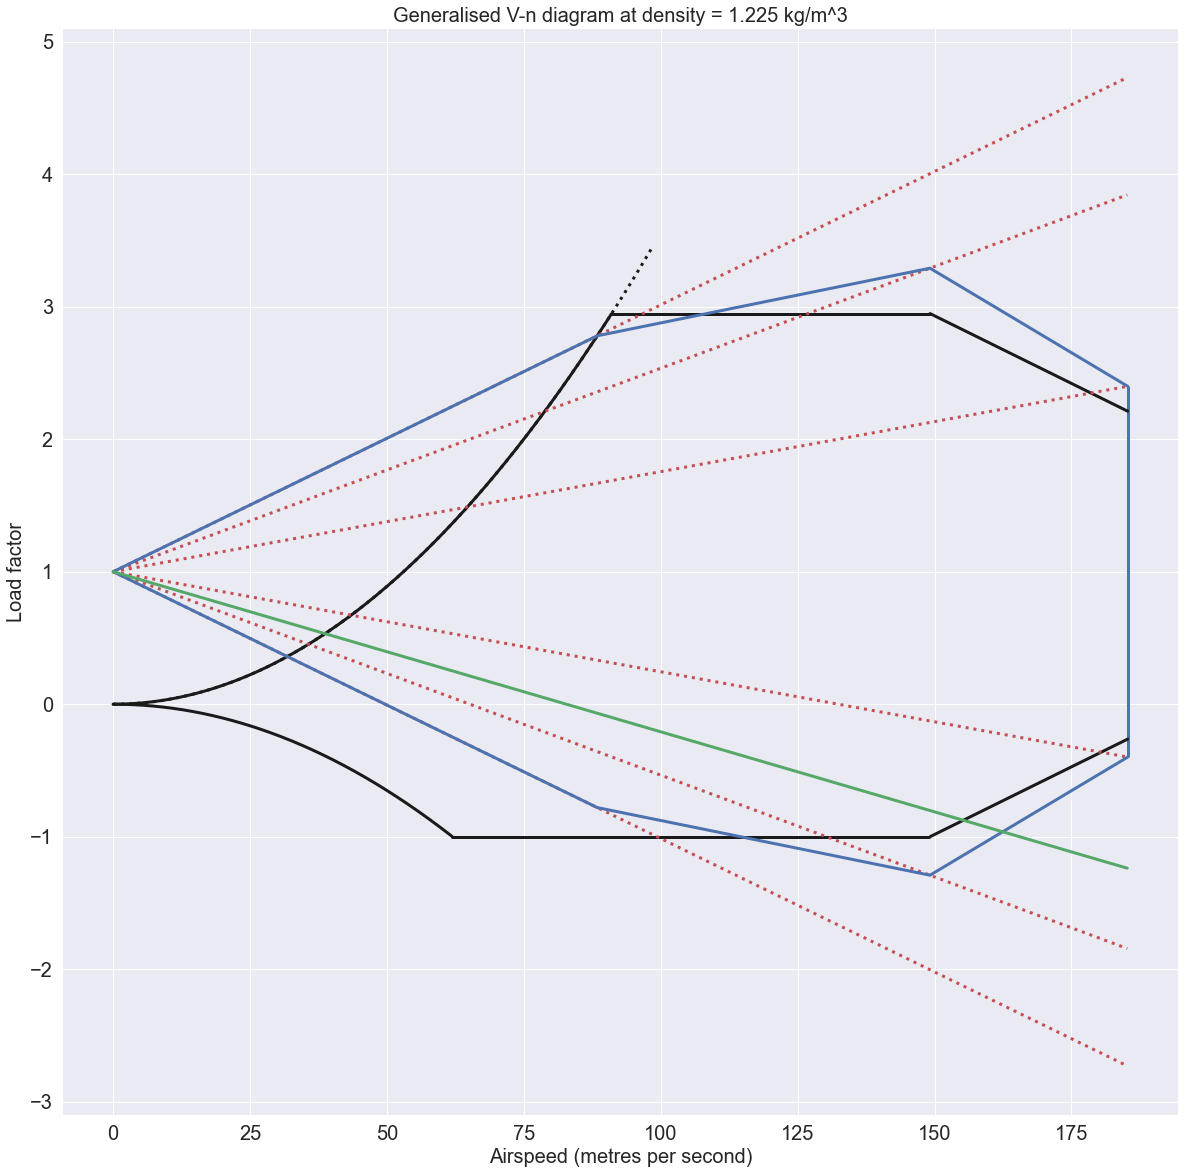

In [21]:
# Generalised V-n Diagram
plt.plot(domain_posstall, positivestall(domain_posstall), color='k')
plt.plot(domain_negstall, negativestall(domain_negstall), color='k')
plt.plot(domain_poslimit, poslimit(domain_poslimit), color='k')
plt.plot(domain_neglimit, neglimit(domain_neglimit), color='k')
plt.vlines(x=V_D, ymin=neg_dive_ylimit, ymax=pos_dive_ylimit, colors='k')
plt.plot(domain_betaline, betalimit(pos_beta_grad, pos_beta_intercept, domain_betaline), color='k')
plt.plot(domain_betaline, betalimit(neg_beta_grad, neg_beta_intercept, domain_betaline), color='k')

# Dotted extension of stall lines
stall_domain = np.arange(0, V_AG + 10, 0.1)
plt.plot(stall_domain, positivestall(stall_domain), color='k', linestyle=":")

# Gust lines
gust_domain = np.arange(0, V_D, 0.1)
plt.plot(gust_domain, (1 + (density * gust_domain * area * lift_slope * u_stall)/(2 * weight)), color='r', linestyle=":")
plt.plot(gust_domain, (1 + (density * gust_domain * area * lift_slope * u_cruise)/(2 * weight)), color='r', linestyle=":")
plt.plot(gust_domain, (1 + (density * gust_domain * area * lift_slope * u_dive)/(2 * weight)), color='r', linestyle=":")
plt.plot(gust_domain, (1 - (density * gust_domain * area * lift_slope * u_stall)/(2 * weight)), color='r', linestyle=":")
plt.plot(gust_domain, (1 - (density * gust_domain * area * lift_slope * u_cruise)/(2 * weight)), color='r', linestyle=":")
plt.plot(gust_domain, (1 - (density * gust_domain * area * lift_slope * u_dive)/(2 * weight)), color='r', linestyle=":")


# Gust V-n Diagram
gust_line(0, V_AG, 1, n_AG)
gust_line(V_AG, V_CG, n_AG, n_CG)
gust_line(V_CG, V_DG, n_CG, n_DG)
gust_line(0, V_AG, 1, 2-n_AG)
gust_line(V_AG, V_CG, 2-n_AG, 2-n_CG)
gust_line(V_CG, V_DG, 2-n_CG, 2-n_DG)
plt.vlines(x=V_D, ymin=2-n_DG, ymax=n_DG, colors='b')

# Special gust line at u = 12.0 m/s
plt.plot(gust_domain, (1 - (density * gust_domain * area * lift_slope * 12.0)/(2 * weight)), color='g')


# Append the plots above.

plt.ylabel('Load factor')
plt.xlabel('Airspeed (metres per second)')
title_str = str("Generalised V-n diagram at density = " + str(density) + " kg/m^3")
plt.title(title_str)
plt.grid(True)
plt.show()

## Appendix: Calculations

Calculations for part (a):

In [22]:
print("Sea")

sea_pstallcoeff = (1.225 * area * max_lift_coeff)/(2 * weight)
print("Positive lift stall curve coefficient:\t", sea_pstallcoeff)

sea_nstallcoeff = (1.225 * area * min_lift_coeff)/(2 * weight)
print("Negative lift stall curve coefficient:\t", sea_nstallcoeff)

V_stall_1 = (1/sea_pstallcoeff)**(0.5)
print("Stall speed at sea level, n = 1:\t", V_stall_1)

print("7000 m")

k7_pstallcoeff = (0.5900 * area * max_lift_coeff)/(2 * weight)
print("Positive lift stall curve coefficient:\t", sea_pstallcoeff)

k7_nstallcoeff = (0.5900 * area * min_lift_coeff)/(2 * weight)
print("Negative lift stall curve coefficient:\t", sea_nstallcoeff)

V_stall_2 = (1/k7_pstallcoeff)**(0.5)
print("Stall speed at 7000 metres, n = 1:\t", V_stall_2)

Sea
Positive lift stall curve coefficient:	 0.0003557537028849342
Negative lift stall curve coefficient:	 -0.0002604210112621741
Stall speed at sea level, n = 1:	 53.01823739676513
7000 m
Positive lift stall curve coefficient:	 0.0003557537028849342
Negative lift stall curve coefficient:	 -0.0002604210112621741
Stall speed at 7000 metres, n = 1:	 76.39542019071281


## MA3700 V-n Diagram 7000 metres

This is a notebook for the use of sketching the V-n diagram.
Chiefly, the main modification is that of the gust lines.

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
sns.set()

### `pyplot` Parameters

We set the parameters for `pyplot` here.

In [24]:
plt.rcParams["figure.figsize"] = (20,20)
plt.rcParams["axes.labelsize"] = 20
plt.rcParams["axes.titlesize"] = 20
plt.rcParams['lines.linewidth'] = 3
plt.rcParams['lines.markersize'] = 20
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20

### Density Input

For this notebook to work we will have to input the density.

In [25]:
density = 0.5900

### Constants

We define the following constants as follows:

In [26]:
mass = 8300
weight = 8300 * 9.81 
V_C = 537 / 3.6
V_D = 667 / 3.6
area = 30.91
span = 17.0
mean_chord = 1.997
max_lift_coeff = 1.53
min_lift_coeff = -1.12
lift_slope = 4.33
print("Force of weight (N): ", weight)
print("Cruise speed (m/s): ", V_C)
print("Dive speed (m/s): ", V_D)

Force of weight (N):  81423.0
Cruise speed (m/s):  149.16666666666666
Dive speed (m/s):  185.27777777777777


We find the lift stall curve coefficients:

In [27]:
pstallcoeff = (density * area * max_lift_coeff)/(2 * weight)
print("Positive lift stall curve coefficient: ", pstallcoeff)

Positive lift stall curve coefficient:  0.00017134259975682545


In [28]:
nstallcoeff = (density * area * min_lift_coeff)/(2 * weight)
print("Negative lift stall curve coefficient: ", nstallcoeff)

Negative lift stall curve coefficient:  -0.00012542726256708792


We proceed to find the BCAR load factors:

In [29]:
n_1 = 2.1 + 24000/(2.20462 * mass + 10000) # Changed in Version 3
n_2 = 0.75 * n_1
n_3 = 1

if n_2 < 2:
    n_2 = 2

print("n_1: ", n_1)
print("n_2: ", n_2)
print("n_3: ", n_3)

n_1:  2.948106104858567
n_2:  2.211079578643925
n_3:  1


We proceed to find the positive and negative design manoeuvering speeds.

In [30]:
V_A = ((2 * n_1 * weight)/(density * area * max_lift_coeff))**(0.5)
V_F = ((-2 * n_3 * weight)/(density * area * min_lift_coeff))**(0.5)
print("V_A: ", V_A)
print("V_F: ", V_F)

V_A:  131.17131699481618
V_F:  89.290247757548


We set up the diagram and figure for `pyplot` here.

In [31]:
%%capture
fig = plt.figure()
ax = fig.gca()
ax.set_xticks(np.arange(0, 200, 10))
ax.set_yticks(np.arange(-5, 5, 0.2))
print("Diagram set up.")

We try to draw the positive stall curve with the following code here:

In [32]:
domain_posstall = np.arange(0.0, V_A, 0.1)
def positivestall(t):
    return (pstallcoeff) * (t ** 2)
# plt.plot(domain_posstall, positivestall(domain_posstall), color='b')

We try to draw the negative stall curve with the following code here:

In [33]:
domain_negstall = np.arange(0.0, V_F, 0.1)
def negativestall(t):
    return (nstallcoeff) * (t ** 2)
# plt.plot(domain_negstall, negativestall(domain_negstall), color='b')

We try to draw the positive limit load factor curve with the following code here:

In [34]:
domain_poslimit = np.arange(V_A, V_C, 0.1)
def poslimit(t):
    return (n_1 + t - t)
# plt.plot(domain_poslimit, poslimit(domain_poslimit), color='b')

We try to draw the negative limit load factor curve with the following code here:

In [35]:
domain_neglimit = np.arange(V_F, V_C, 0.1)
def neglimit(t):
    return (-n_3 + t - t)
# plt.plot(domain_neglimit, neglimit(domain_neglimit), color='b')

We try to draw the high speed limit vertical line with the following code here:

In [36]:
# plt.vlines(x=V_D, ymin=-n_3, ymax=n_1, colors='b')

The algorithm for the beta lines is as follows.
Firstly, we find the gradient of the top line by taking `(n_2 - n_1)/(V_C - V_A)`
We assign it to a `pos_beta_grad` variable. This will inherently be negative.

We will find the y-intercept by taking `n_1 - pos_beta_grad * V_C`.
We then assign this y-intercept to `pos_beta_intercept`.

We assign it to a (-`pos_beta_grad`) variable to `neg_beta_grad`. This will inherently be
positive. 

We will find the y-intercept by taking `n_3 - neg_beta_grad * V_C`.
We then assign this y-intercept to `neg_beta_intercept`.

We will have to find the limits of the vertical line:
This will be:
`pos_dive_ylimit = pos_beta_grad * V_D + pos_beta_intercept`
and
`neg_dive_ylimit = neg_beta_grad * V_D + neg_beta_intercept`.
We will assign it to the limits of the vertical line.
`plt.vlines(x=V_D, ymin=neg_dive_ylimit, ymax=pos_dive_ylimit, colors='b')`

Lastly, we will have to figure out the appropriate domains:
`domain_betaline = np.arange(V_C, V_D, 0.1)`

And then draw the beta lines accordingly.
```
def betalimit(m,c,t):
    return (m*t + c)
plt.plot(domain_betaline, betalimit(pos_beta_grad, pos_beta_intercept, domain_betaline), color='k')
plt.plot(domain_betaline, betalimit(neg_beta_grad, neg_beta_intercept, domain_betaline), color='k')
```

In [37]:
pos_beta_grad = (n_2 - n_1)/(V_D - V_C)
pos_beta_intercept = n_1 - (pos_beta_grad * V_C)
neg_beta_grad = 0 - pos_beta_grad
neg_beta_intercept = -n_3 - (neg_beta_grad * V_C)
pos_dive_ylimit = (pos_beta_grad * V_D) + pos_beta_intercept
print("Positive dive limit: ", pos_dive_ylimit)
neg_dive_ylimit = (neg_beta_grad * V_D) + neg_beta_intercept
print("Negative dive limit: ", neg_dive_ylimit)
domain_betaline = np.arange(V_C, V_D, 0.1)
def betalimit(m,c,t):
    return (m*t + c)

Positive dive limit:  2.211079578643925
Negative dive limit:  -0.2629734737853586


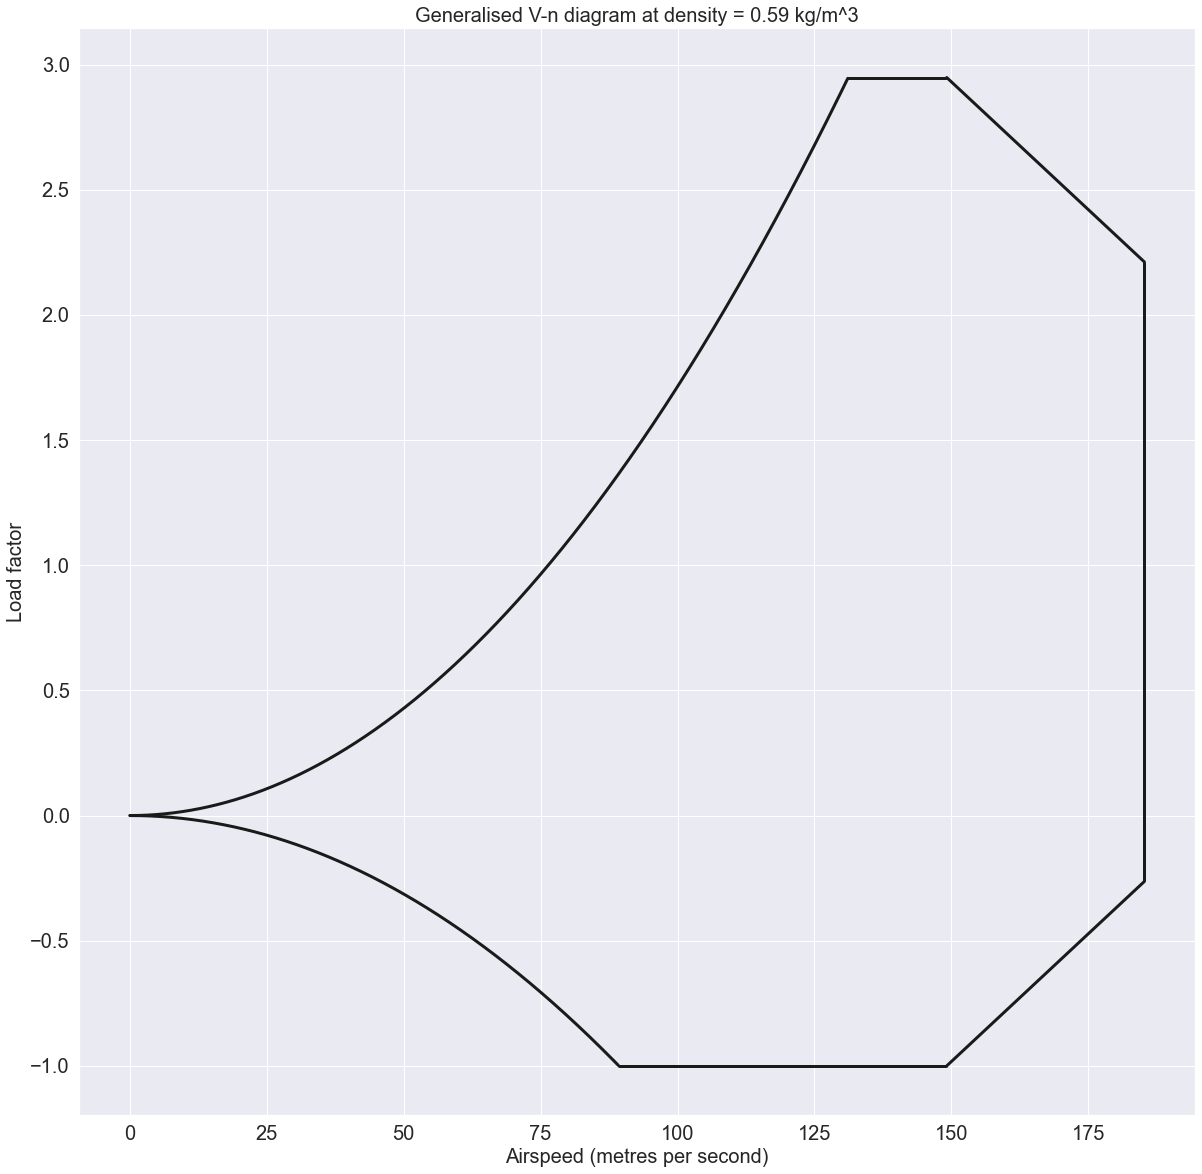

In [38]:
plt.plot(domain_posstall, positivestall(domain_posstall), color='k')
plt.plot(domain_negstall, negativestall(domain_negstall), color='k')
plt.plot(domain_poslimit, poslimit(domain_poslimit), color='k')
plt.plot(domain_neglimit, neglimit(domain_neglimit), color='k')
plt.vlines(x=V_D, ymin=neg_dive_ylimit, ymax=pos_dive_ylimit, colors='k')
plt.plot(domain_betaline, betalimit(pos_beta_grad, pos_beta_intercept, domain_betaline), color='k')
plt.plot(domain_betaline, betalimit(neg_beta_grad, neg_beta_intercept, domain_betaline), color='k')

# Append the plots above.

plt.ylabel('Load factor')
plt.xlabel('Airspeed (metres per second)')
title_str = str("Generalised V-n diagram at density = " + str(density) + " kg/m^3")
plt.title(title_str)
plt.grid(True)
plt.show()

## Gust V-n Diagram

Here is the algorithm used to plot the gust V-n diagram:

The first part requires the solution of the intersection between the gust stall curve and the
gust line u = 20. Iteration is required:

0. Pick epsilon between 1e-5 where difference between n_AG - nAG < 1e-5
1. Guess n_AG = n_1
2. Substitute n_1 to find the gust speed V_AG using the positive lift stall curve `(n_stall = pstallcoeff * (V_stall ** 2)`.
3. Substiute V_AG to find n_AG2
4. Iterate WHILE n_AG2 - n_AG > 1e-5. If it does, stop the algorithm. Assign n_AG2 = n_AG, print the value.

In [39]:
u_stall = 11.6
eps = 1e-5
n_AG = n_1
n_AG2 = 0
while True:
    # V_AG = ((2*n_AG*weight)/(density*area*max_lift_coeff))**(0.5)
    V_AG = ((n_AG)/(pstallcoeff))**(0.5)
    # print(V_AG)
    n_AG2 = 1 + (density * V_AG * area * lift_slope * u_stall)/(2 * weight)
    # print(n_AG)
    # print(n_AG2)
    if abs(n_AG - n_AG2) < eps:
        break
    else:
        n_AG = n_AG2
    # print(n_AG)
    # print(n_AG2)
print("V_AG: ", V_AG)
print("n_AG: ", n_AG)

V_AG:  94.5534744383099
n_AG:  1.5318644443492442


In [40]:
u_cruise = 7.6
V_CG = V_C
n_CG = 1 + (density * V_CG * area * lift_slope * u_cruise)/(2 * weight)
print("V_CG: ", V_CG)
print("n_CG: ", n_CG)

V_CG:  149.16666666666666
n_CG:  1.5497271605832095


In [41]:
u_dive = 3.8
V_DG = V_D
n_DG = 1 + (density * V_DG * area * lift_slope * u_dive)/(2 * weight)
print("V_DG: ", V_DG)
print("n_DG: ", n_DG)

V_DG:  185.27777777777777
n_DG:  1.341404111833334


In [42]:
def gust_line(V_1, V_2, n_1, n_2):
    """Procedure. Plots the y-value associated with the gust line. V_2 > V_1"""
    gradient = (n_2 - n_1)/(V_2 - V_1)
    intercept = n_2 - gradient * V_2
    domain = np.arange(V_1, V_2, 0.1)
    plt.plot(domain, ((gradient * domain) + intercept), color='b')

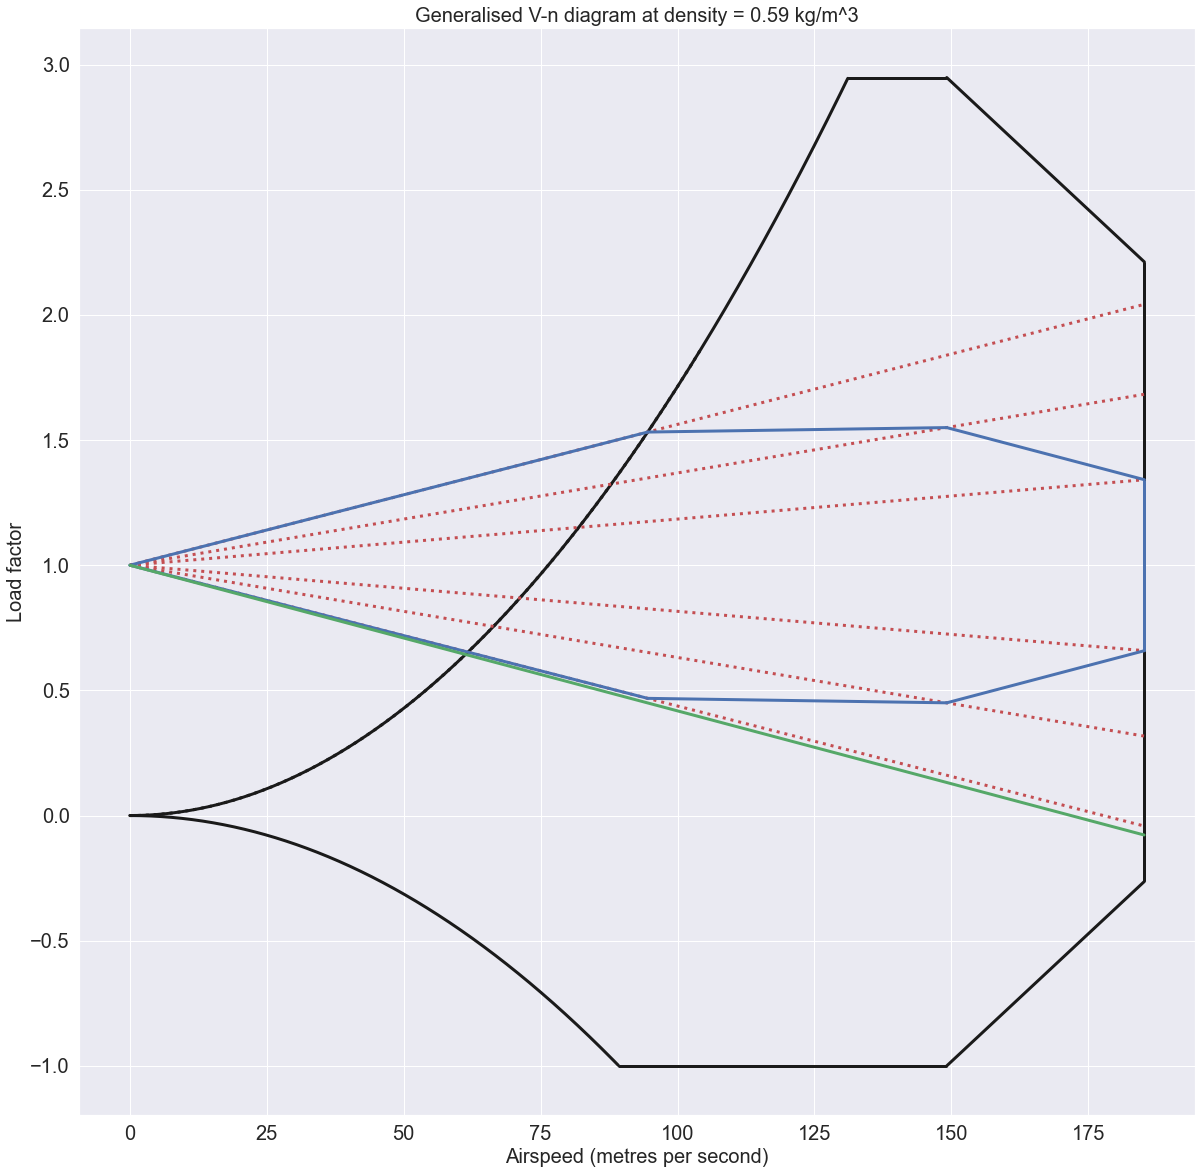

In [43]:
# Generalised V-n Diagram
plt.plot(domain_posstall, positivestall(domain_posstall), color='k')
plt.plot(domain_negstall, negativestall(domain_negstall), color='k')
plt.plot(domain_poslimit, poslimit(domain_poslimit), color='k')
plt.plot(domain_neglimit, neglimit(domain_neglimit), color='k')
plt.vlines(x=V_D, ymin=neg_dive_ylimit, ymax=pos_dive_ylimit, colors='k')
plt.plot(domain_betaline, betalimit(pos_beta_grad, pos_beta_intercept, domain_betaline), color='k')
plt.plot(domain_betaline, betalimit(neg_beta_grad, neg_beta_intercept, domain_betaline), color='k')

# Dotted extension of stall lines
stall_domain = np.arange(0, V_AG + 10, 0.1)
plt.plot(stall_domain, positivestall(stall_domain), color='k', linestyle=":")

# Gust lines
gust_domain = np.arange(0, V_D, 0.1)
plt.plot(gust_domain, (1 + (density * gust_domain * area * lift_slope * u_stall)/(2 * weight)), color='r', linestyle=":")
plt.plot(gust_domain, (1 + (density * gust_domain * area * lift_slope * u_cruise)/(2 * weight)), color='r', linestyle=":")
plt.plot(gust_domain, (1 + (density * gust_domain * area * lift_slope * u_dive)/(2 * weight)), color='r', linestyle=":")
plt.plot(gust_domain, (1 - (density * gust_domain * area * lift_slope * u_stall)/(2 * weight)), color='r', linestyle=":")
plt.plot(gust_domain, (1 - (density * gust_domain * area * lift_slope * u_cruise)/(2 * weight)), color='r', linestyle=":")
plt.plot(gust_domain, (1 - (density * gust_domain * area * lift_slope * u_dive)/(2 * weight)), color='r', linestyle=":")


# Gust V-n Diagram
gust_line(0, V_AG, 1, n_AG)
gust_line(V_AG, V_CG, n_AG, n_CG)
gust_line(V_CG, V_DG, n_CG, n_DG)
gust_line(0, V_AG, 1, 2-n_AG)
gust_line(V_AG, V_CG, 2-n_AG, 2-n_CG)
gust_line(V_CG, V_DG, 2-n_CG, 2-n_DG)
plt.vlines(x=V_D, ymin=2-n_DG, ymax=n_DG, colors='b')

# Special gust line at u = 12.0 m/s
plt.plot(gust_domain, (1 - (density * gust_domain * area * lift_slope * 12.0)/(2 * weight)), color='g')


# Append the plots above.

plt.ylabel('Load factor')
plt.xlabel('Airspeed (metres per second)')
title_str = str("Generalised V-n diagram at density = " + str(density) + " kg/m^3")
plt.title(title_str)
plt.grid(True)
plt.show()

## Appendix: Calculations

Calculations for part (a):

In [44]:
print("Sea")

sea_pstallcoeff = (1.225 * area * max_lift_coeff)/(2 * weight)
print("Positive lift stall curve coefficient:\t", sea_pstallcoeff)

sea_nstallcoeff = (1.225 * area * min_lift_coeff)/(2 * weight)
print("Negative lift stall curve coefficient:\t", sea_nstallcoeff)

V_stall_1 = (1/sea_pstallcoeff)**(0.5)
print("Stall speed at sea level, n = 1:\t", V_stall_1)

print("7000 m")

k7_pstallcoeff = (0.5900 * area * max_lift_coeff)/(2 * weight)
print("Positive lift stall curve coefficient:\t", sea_pstallcoeff)

k7_nstallcoeff = (0.5900 * area * min_lift_coeff)/(2 * weight)
print("Negative lift stall curve coefficient:\t", sea_nstallcoeff)

V_stall_2 = (1/k7_pstallcoeff)**(0.5)
print("Stall speed at 7000 metres, n = 1:\t", V_stall_2)

Sea
Positive lift stall curve coefficient:	 0.0003557537028849342
Negative lift stall curve coefficient:	 -0.0002604210112621741
Stall speed at sea level, n = 1:	 53.01823739676513
7000 m
Positive lift stall curve coefficient:	 0.0003557537028849342
Negative lift stall curve coefficient:	 -0.0002604210112621741
Stall speed at 7000 metres, n = 1:	 76.39542019071281
